# Objektklassifikation

In dieser ersten Demo werden wir uns genauer mit **Objektklassifikation** auseinandersetzen.
Dabei befassen wir uns mit der folgenden Frage:

*„Was ist auf diesem Bild zu sehen?“*

In dieser Demo verwenden wir ein vortrainiertes Klassifikationsmodell (ein YOLO-Modell -
dazu später mehr), das auf vielen unterschiedlichen Bildkategorien trainiert wurde. 
Es kann daher zum Beispiel out-of-the-box zwischen Tieren, Fahrzeugen oder Alltagsgegenständen
unterscheiden.

Schauen wir uns an, wie das funktionieren kann!

## Für die Benutzung von Google Colab...

In [ ]:
# nötige Packages installieren...
!pip install opencv-python matplotlib ultralytics numpy

# drive mounten, damit wir auf die Bilder/Videos zugreifen können
from google.colab import drive
drive.mount('/content/drive')

## Ein Bild laden (das Computer-Vision-Äquivalent zu “Hello World”)

Wir starten ganz basic: Wir laden ein Bild aus unserem Root-Ordner in Python. Im nächsten Schritt schauen wir es uns
dann direkt an, damit wir wissen, womit wir arbeiten.

Für diese Schritte nutzen wir das **opencv-python**-package (`cv2`).

In [ ]:
import cv2

# Pfad zum Bild (anpassen!)

# für Colab: 
# img_path = "/content/drive/MyDrive/DIH-CV-main/images/cats/cat1.jpg"
img_path = "/home/u88m52/projects/DIH-CV/images/cats/cat1.jpg"
img_bgr = cv2.imread(img_path)

# Kurzer Check (img_bgr sollte nicht None sein - falls doch, Pfad prüfen!)
print("Laden erfolgreich?", img_bgr is not None)

Laden erfolgreich? True


Wir haben gerade das Bild mit OpenCV geladen und kurz geprüft, ob das Laden geklappt hat
(`False` würde bedeuten: geladenes Objekt ist `None`, also der Pfad stimmt nicht oder
die Datei wurde nicht gefunden).

Als nächstes visualisieren wir das Bild!

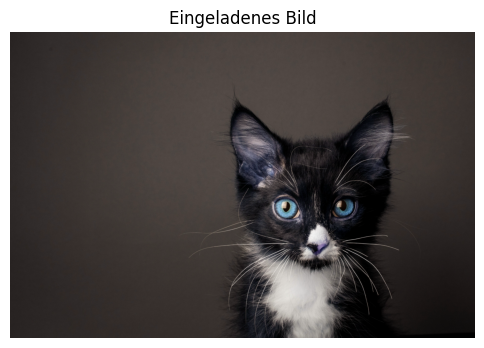

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(img_bgr)
plt.axis("off")
plt.title("Eingeladenes Bild")
plt.show()

Wir haben das Foto jetzt korrekt geladen - aber die Farben sind völlig verfälscht. 
Was ist schiefgelaufen?

- `ovencv` lädt Bilder im BGR-Format, d.h. die drei Farbkanäle werden in der Reihenfolge
  blau-grün-rot angeordnet. Unser Visualisierungspackage, `matplotlib.pyplot`, nimmt
  allerdings eine Reihenfolge rot-grün-blau an - wir müssen das Bild also vorher noch
  in eine üblichere Farbcodierung bringen.

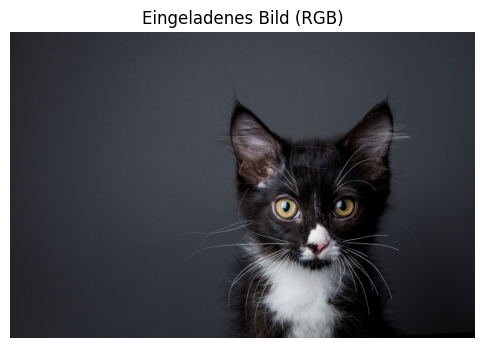

In [10]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Eingeladenes Bild (RGB)")
plt.show()

Jetzt ist alles richtig visualisiert!

Wir haben uns das Bild jetzt angeschaut und wissen: es sieht “normal” aus und ist korrekt geladen. 
Als nächstes untersuchen wir die Form (Shape) des Bildarrays. Dabei sehen wir typischerweise:
Höhe × Breite × Farbkanäle. Im Falle von Graustufenbildern hätten wir nur einen einzigen
Farbkanal - wir können also ein Graustufenbild erzeugen, indem wir z.B. über unser
Farbkanäle drübermitteln.

Sehen wir uns das für unser Testbild genauer an:

In [12]:
print("Shape (H, W, C):", img_rgb.shape)
print("Datentyp:", img_rgb.dtype)

H, W, C = img_rgb.shape
print("Höhe:", H, "Breite:", W, "Kanäle:", C)

Shape (H, W, C): (2475, 3758, 3)
Datentyp: uint8
Höhe: 2475 Breite: 3758 Kanäle: 3


Wir haben gerade gesehen: Das Bild hat drei Kanäle (C=3) – das sind die Farbkanäle (RGB).

Als nächstes machen wir daraus eine “Graustufen”-Variante, indem wir über die drei Kanäle mitteln.
Dann plotten wir dieses Ergebnis, um zu sehen: es ist jetzt nur noch ein 2D-Bild (H × W).

Shape Graustufen (H, W): (2475, 3758)
Min/Max: 0.0 255.0


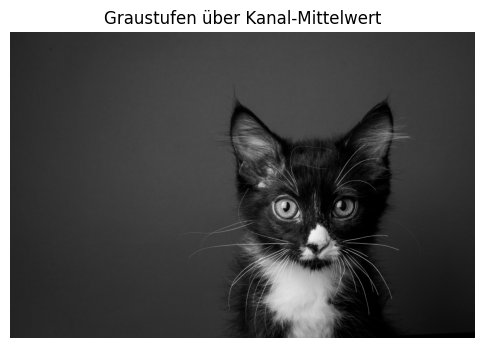

In [13]:
# Mittelwert über die Farbkanäle -> Graustufenbild (float)
img_gray_mean = img_rgb.mean(axis=2)

print("Shape Graustufen (H, W):", img_gray_mean.shape)
print("Min/Max:", img_gray_mean.min(), img_gray_mean.max())

plt.figure(figsize=(6, 4))
plt.imshow(img_gray_mean, cmap="gray")
plt.axis("off")
plt.title("Graustufen über Kanal-Mittelwert")
plt.show()

## Ein vortrainiertes Klassifikationsmodell laden

Wir haben aus dem RGB-Bild ein Graustufenbild erzeugt, indem wir über die drei Kanäle gemittelt haben.
Man erkennt: Die Form ist jetzt (H, W) statt (H, W, 3).

Nachdem wir jetzt ein wenig mit dem Testbild gespielt haben, fokussieren wir uns jetzt
darauf, was wir auf dem Bild überhaupt sehen können: eine Katze.

Wir hätten aber nun gerne, dass wir das nicht selber feststellen müssen - stattdessen
werden wir schnell eines der praktischsten vortrainierten Computer Vision Modelle für
Objektklassifizierung laden: ein Modell der YOLO-Modellfamilie (später mehr dazu).

In [15]:
from ultralytics import YOLO

clf_model = YOLO("yolo11s-cls.pt")
clf_model

YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_runni

## Das Modell verwenden..

Wir haben jetzt ein Klassifikationsmodell geladen - um genau zu sein, `Yolo11s`. Das
Modell stammt aus der 11. Generation der YOLO-Modellfamilie und, wie die meisten der
Modelle, ist es in verschiedenen Größen (Anzahl der Parameter) verfügbar. Das `s` (small)
Modell liefert dabei normalerweise einen guten Trade-off zwischen Größe und Performance.

Über `clf_model` lässt sich die Architektur des Modells auch genauer anschauen - wie man
sieht gibt es hier 10 verschiedene Layer-Blöcke, wobei der letzte Block (10) die finale
Klassifikation übernimmt. Im letzten linearen (fully connected) Layer wird der Output
schließlich auf die Größe `1000` gesetzt - das ist kein Zufall. Dieses Modell wurde auf
einem Datensatz mit 1000 Klassen vortrainiert.

Jetzt wo wir das Modell geladen haben, wollen wir es natürlich unser Bild analysieren
lassen:

In [25]:
# Wir können direkt den Pfad verwenden (Ultralytics lädt das Bild selbst)
result = clf_model.predict(img_path, verbose=False)

print("Typ von result:", type(result))
print("Anzahl Results:", len(result))
print("Typ result[0]:", type(result[0]))

Typ von res: <class 'list'>
Anzahl Results: 1
Typ res[0]: <class 'ultralytics.engine.results.Results'>


Wir haben die Klassifikation ausgeführt und sehen: `predict()` liefert eine Liste von Result-Objekten zurück
(eins pro Input-Bild). Für unser einzelnes Bild ist das also `result[0]`.

Als nächstes schauen wir in dieses Result hinein:
Welche Felder gibt es? Wo stecken die Wahrscheinlichkeiten? Welche Form haben sie?

In [29]:
r0 = result[0]

# Was ist im Result-Objekt drin?
print("Verfügbare Attribute (Ausschnitt):")
attrs = [a for a in dir(r0) if not a.startswith("_")]
print(attrs[:40], "...")

print("\nNames verfügbar?", hasattr(r0, "names"))
print("Probs verfügbar?", hasattr(r0, "probs"))
print("Boxes verfügbar?", hasattr(r0, "boxes"))

Verfügbare Attribute (Ausschnitt):
['boxes', 'cpu', 'cuda', 'keypoints', 'masks', 'names', 'new', 'numpy', 'obb', 'orig_img', 'orig_shape', 'path', 'plot', 'probs', 'save', 'save_crop', 'save_dir', 'save_txt', 'show', 'speed', 'summary', 'to', 'to_csv', 'to_df', 'to_json', 'update', 'verbose'] ...

Names verfügbar? True
Probs verfügbar? True
Boxes verfügbar? True
{0: 'tench', 1: 'goldfish', 2: 'great_white_shark', 3: 'tiger_shark', 4: 'hammerhead', 5: 'electric_ray', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich', 10: 'brambling', 11: 'goldfinch', 12: 'house_finch', 13: 'junco', 14: 'indigo_bunting', 15: 'robin', 16: 'bulbul', 17: 'jay', 18: 'magpie', 19: 'chickadee', 20: 'water_ouzel', 21: 'kite', 22: 'bald_eagle', 23: 'vulture', 24: 'great_grey_owl', 25: 'European_fire_salamander', 26: 'common_newt', 27: 'eft', 28: 'spotted_salamander', 29: 'axolotl', 30: 'bullfrog', 31: 'tree_frog', 32: 'tailed_frog', 33: 'loggerhead', 34: 'leatherback_turtle', 35: 'mud_turtle', 36: 'terrapin', 37

Wie erwähnt ist das YOLO Klassifizierungsmodell auf 1000 Objektklassen trainiert worden;
wird können sie auch aus dem Resultat auslesen:

In [30]:
print("Verfügbare Objektklassen", r0.names)

Verfügbare Objektklassen {0: 'tench', 1: 'goldfish', 2: 'great_white_shark', 3: 'tiger_shark', 4: 'hammerhead', 5: 'electric_ray', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich', 10: 'brambling', 11: 'goldfinch', 12: 'house_finch', 13: 'junco', 14: 'indigo_bunting', 15: 'robin', 16: 'bulbul', 17: 'jay', 18: 'magpie', 19: 'chickadee', 20: 'water_ouzel', 21: 'kite', 22: 'bald_eagle', 23: 'vulture', 24: 'great_grey_owl', 25: 'European_fire_salamander', 26: 'common_newt', 27: 'eft', 28: 'spotted_salamander', 29: 'axolotl', 30: 'bullfrog', 31: 'tree_frog', 32: 'tailed_frog', 33: 'loggerhead', 34: 'leatherback_turtle', 35: 'mud_turtle', 36: 'terrapin', 37: 'box_turtle', 38: 'banded_gecko', 39: 'common_iguana', 40: 'American_chameleon', 41: 'whiptail', 42: 'agama', 43: 'frilled_lizard', 44: 'alligator_lizard', 45: 'Gila_monster', 46: 'green_lizard', 47: 'African_chameleon', 48: 'Komodo_dragon', 49: 'African_crocodile', 50: 'American_alligator', 51: 'triceratops', 52: 'thunder_snake', 53: 'r

Wir wissen jetzt, welche Attribute im Result-Objekt grundsätzlich existieren, und welche
Klassen es überhaupt gibt. Was für uns jetzt primär von Interesse ist, ist das Attribut 
`probs` (Wahrscheinlichkeiten über die Klassen).

Als nächstes greifen wir also `r0.probs` ab und schauen:
- welche ist die Top-Klasse, und wie ist ihre Konfidenz
- welche Klassen sind in den Top 5

In [36]:
probs = r0.probs

print("Typ probs:", type(probs))

# Top-1
top1_id = int(probs.top1)
top1_conf = float(probs.top1conf)
top1_name = r0.names[top1_id]

print("Top class ID:", top1_id)
print("Top class Name:", top1_name)
print("Top class Konfidenz:", f"{float(top1_conf):.2f}")

# Top-5
print("\nTop-5:")
for cls_id, conf in zip(probs.top5, probs.top5conf):
    cls_id = int(cls_id)
    print(f"- {r0.names[cls_id]:<25} {float(conf):.2f}")

Typ probs: <class 'ultralytics.engine.results.Probs'>
Top class ID: 285
Top class Name: Egyptian_cat
Top class Konfidenz: 0.38

Top-5:
- Egyptian_cat              0.38
- tabby                     0.25
- tiger_cat                 0.10
- Siamese_cat               0.06
- feather_boa               0.05


Wir haben jetzt die Top-1- und Top-5-Vorhersagen ausgelesen: die Klasse mit der höchsten
Konfidenz ist in diesem Fall `Egyptian_cat`, und auch drei weitere der Top-5 Klassen
bezeichnen Katzenarten - das hat also ganz gut funktioniert.

Als nächstes schauen wir uns die Wahrscheinlichkeitsverteilung als Vektor an:
- Welche Form hat sie?
- Wie viele Klassen stecken dahinter?
- (Optional) Wie verteilt ist die Wahrscheinlichkeit insgesamt?

In [38]:
import numpy as np

p = probs.data.cpu().numpy()  # kompletter Wahrscheinlichkeitsvektor

print("Shape des Wahrscheinlichkeitsvektors:", p.shape)
print("Summe (sollte ~1 sein):", p.sum())
print("Min/Max:", p.min(), p.max())

sorted_p = np.sort(p)[::-1]
print("\nTop-10 Wahrscheinlichkeiten:", sorted_p[:10])

Shape des Wahrscheinlichkeitsvektors: (1000,)
Summe (sollte ~1 sein): 0.99999964
Min/Max: 5.6125376e-08 0.38060075

Top-10 Wahrscheinlichkeiten: [     0.3806     0.24753     0.10253     0.05817    0.052201    0.022821    0.011519     0.01147   0.0074439   0.0045133]


## Visualisierung der Ergebnisse

Der Wahrscheinlichkeitsvektor weist also tatsächlich jeder der Objektklassen, auf die
trainiert wurde, eine Wahrscheinlichkeit zu - und die Gesamtwahrscheinlichkeit über alle
Klassen hinweg summiert sich korrekterweise auf (etwa) 1 auf.

Wir können die Top-5 Klassen auch als Balkendiagramm plotten, um einen schnelleren
Überblick zu erhalten:

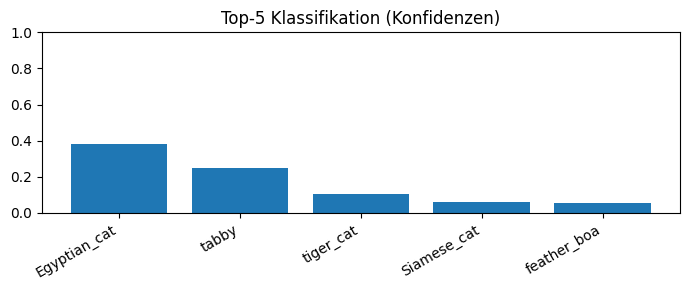

In [39]:
topk = 5
topk_ids = [int(x) for x in probs.top5[:topk]]
topk_confs = [float(x) for x in probs.top5conf[:topk]]
topk_names = [r0.names[i] for i in topk_ids]

plt.figure(figsize=(7, 3))
plt.bar(topk_names, topk_confs)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Top-5 Klassifikation (Konfidenzen)")
plt.tight_layout()
plt.show()

## Andere Testbilder...
Das hat bisher alles gut funktioniert - aber sehen wir uns das jetzt auch noch für andere
Bilder an.

In [ ]:
# In Colab:
# img_path = "/content/drive/MyDrive/DIH-CV-main/images/cats"

img_path = "/home/u88m52/projects/DIH-CV/images/cats"
result = clf_model.predict(img_path, verbose=False)
print("Anzahl der Bilder im Result:", len(result))

Anzahl der Bilder im Result: 5


Wie man sieht, ist YOLO so flexibel, dass wir sogar einfach einen Ordner angeben können.
Unser Resultat hat dann plötzlich 5 Einträge, da in diesem Ordner 5 Bilder liegen.

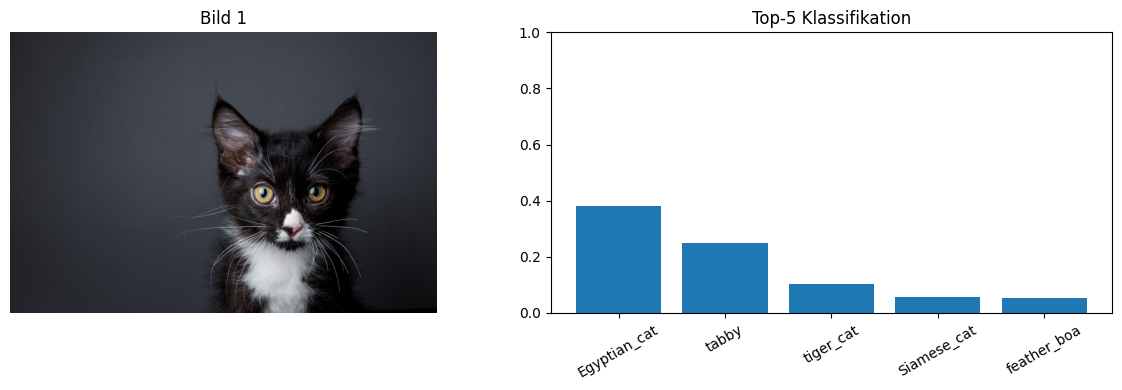

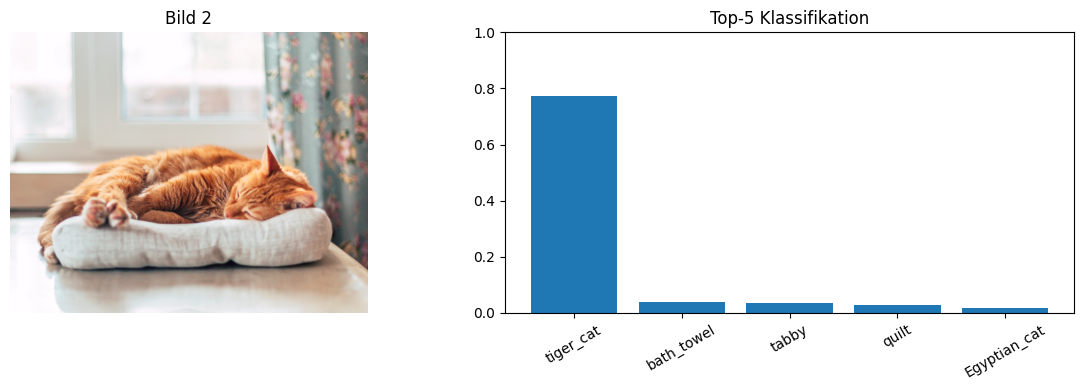

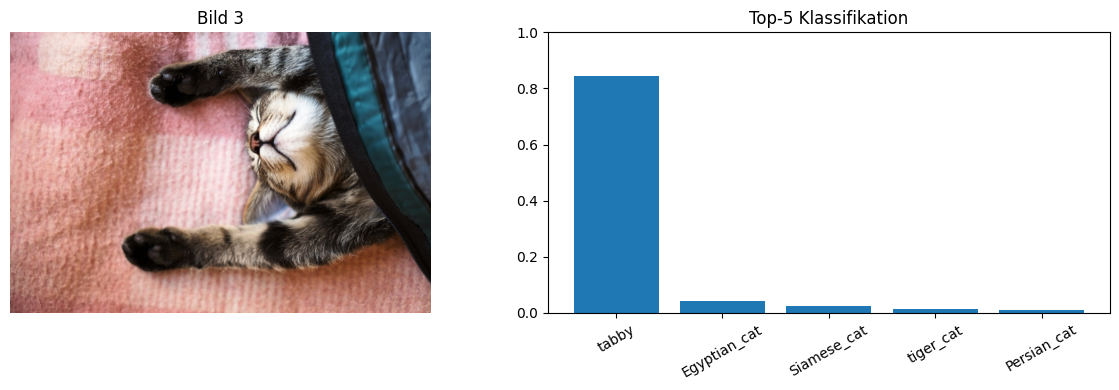

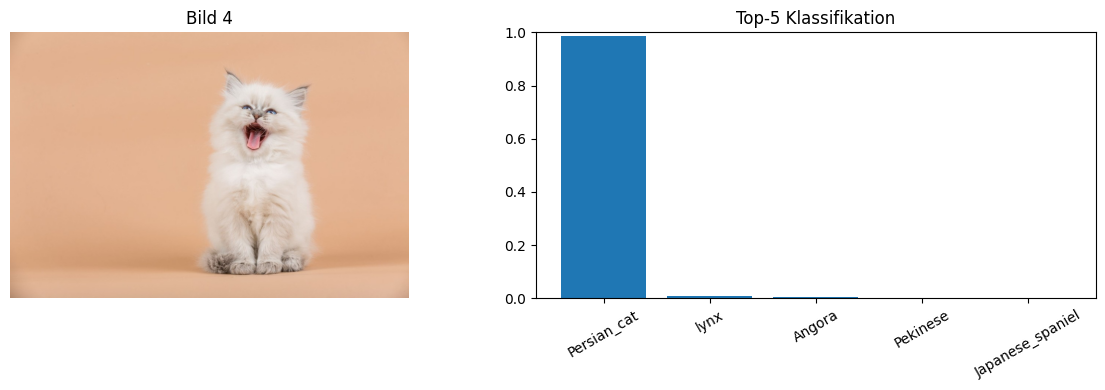

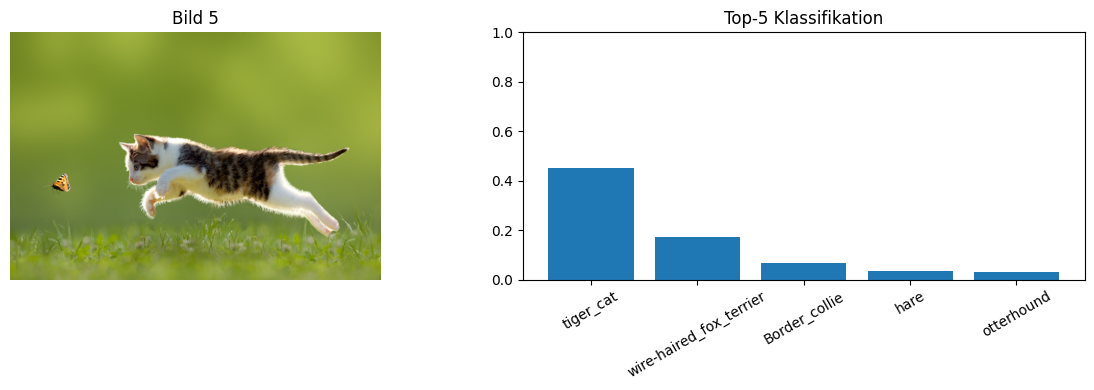

In [ ]:
for i, r in enumerate(result):
    # wir laden zuerst das konkrete Bild
    img_path = r.path  
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # wir extrahieren die Top-5 Klassifikationsdaten
    probs = r.probs
    topk = 5
    topk_ids = [int(x) for x in probs.top5[:topk]]
    topk_confs = [float(x) for x in probs.top5conf[:topk]]
    topk_names = [r.names[i] for i in topk_ids]

    # wir plotten alles in Subplots - Bild links, Balkendiagramm rechts
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img_rgb)
    axes[0].axis("off")
    axes[0].set_title(f"Bild {i+1}")

    axes[1].bar(topk_names, topk_confs)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Top-5 Klassifikation")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


## Trouble in Paradise: Unbekannte Klassen

Das Modell war sich hier immer sehr sicher, dass es sich um (zumindest irgendeine Art
von) Katze handelt.

Wie sieht es aber aus, wenn wir uns sehr ungewöhnliche Tiere ansehen?

Anzahl der Bilder im Result: 6


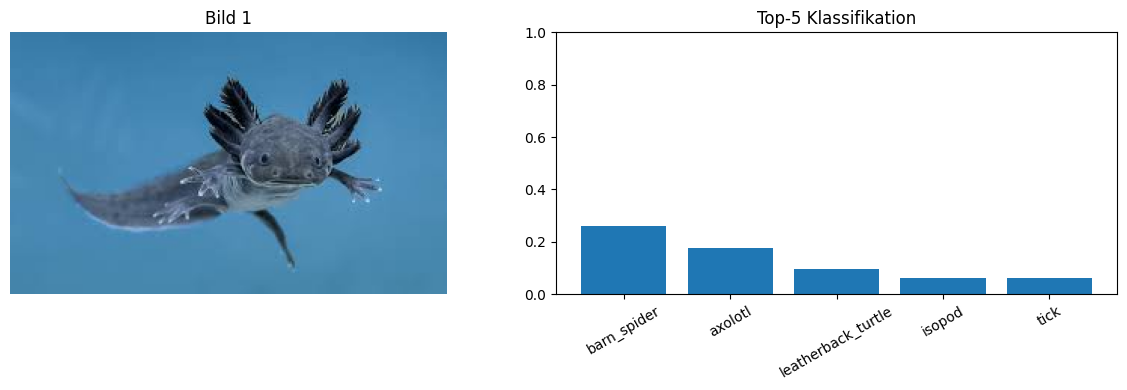

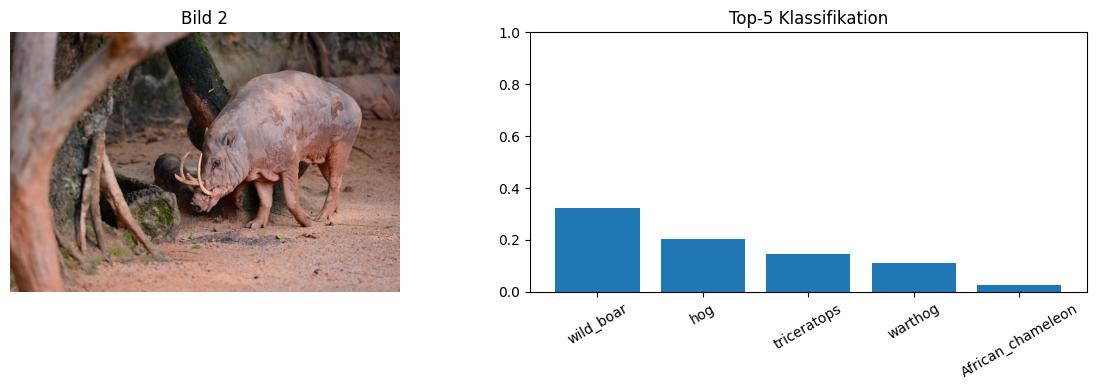

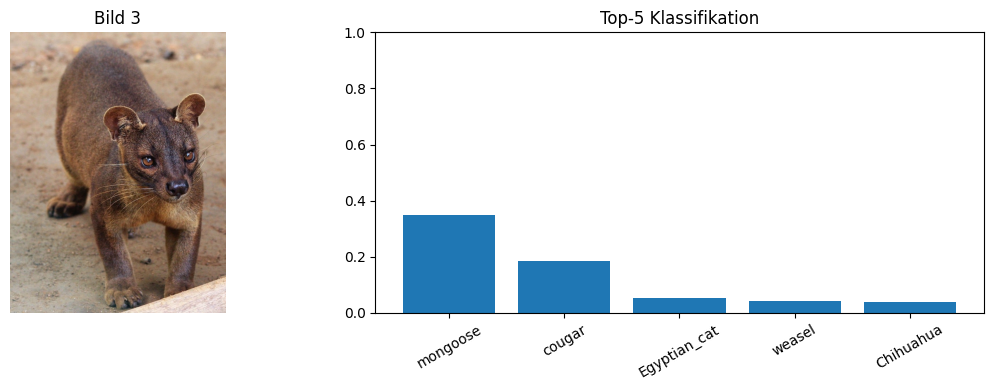

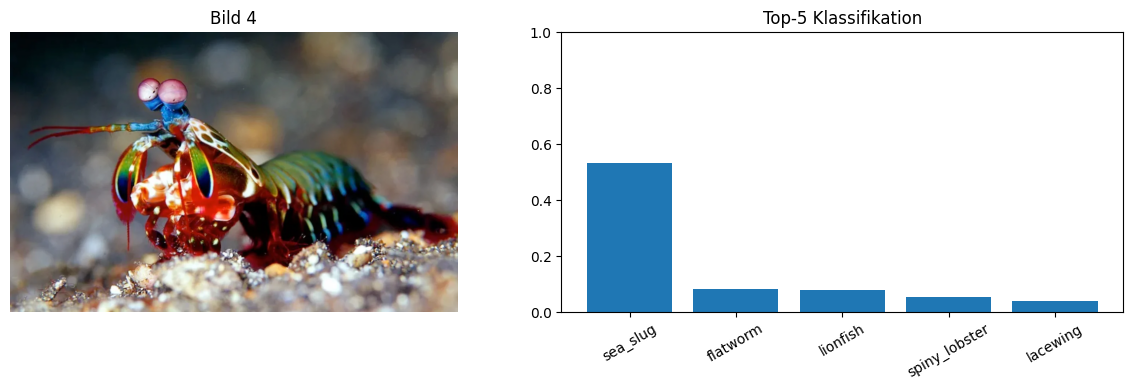

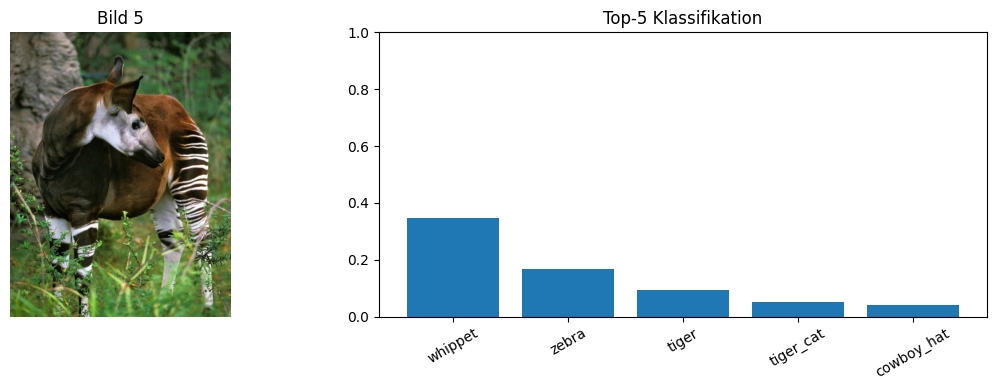

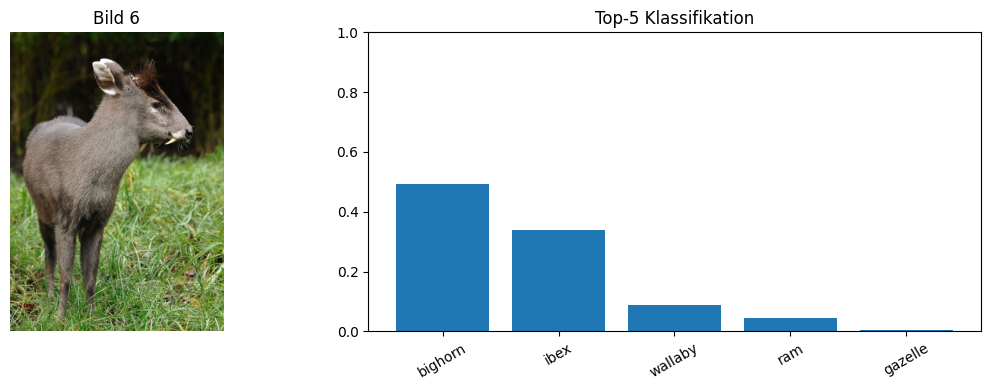

In [ ]:
# In Colab:
# img_path = "/content/drive/MyDrive/DIH-CV-main/images/diverse"

img_path = "/home/u88m52/projects/DIH-CV/images/diverse"
result = clf_model.predict(img_path, verbose=False)
print("Anzahl der Bilder im Result:", len(result))

for i, r in enumerate(result):
    # wir laden zuerst das konkrete Bild
    img_path = r.path  
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # wir extrahieren die Top-5 Klassifikationsdaten
    probs = r.probs
    topk = 5
    topk_ids = [int(x) for x in probs.top5[:topk]]
    topk_confs = [float(x) for x in probs.top5conf[:topk]]
    topk_names = [r.names[i] for i in topk_ids]

    # wir plotten alles in Subplots - Bild links, Balkendiagramm rechts
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img_rgb)
    axes[0].axis("off")
    axes[0].set_title(f"Bild {i+1}")

    axes[1].bar(topk_names, topk_confs)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Top-5 Klassifikation")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

Hier wird's schon deutlich schwieriger, da die Objektklassen, die wir gerne
identifiziert hätten (Babirusa, Fossa, Mantis Shrimp, Okapi, Tufted Deer), nicht im
Trainingsdatensatz enthalten waren - diese Klassen sind nicht unter den 1000, die das
Modell unterscheiden kann.

Das ist allerdings beim Menschen nicht anders - hätten Sie diese Tiere benennen können??

Wichtigste Botschaft hier: **worauf nicht trainiert wurde (was nicht "gelernt" wurde), kann
auch nicht identifiziert werden.**

## Multi-Object Bilder: Was passiert bei Klassifikation?

Wir testen jetzt Bilder, auf denen mehrere Objekte vorkommen (z.B. Katze + Hund).
Wichtig: in der Klassifikation gibt es trotzdem **nur ein Label pro Bild**.

Anzahl der Bilder im Result: 5


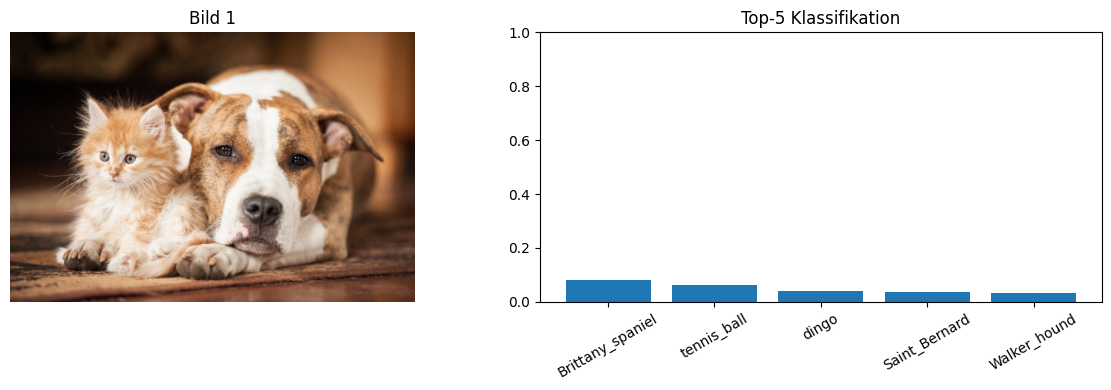

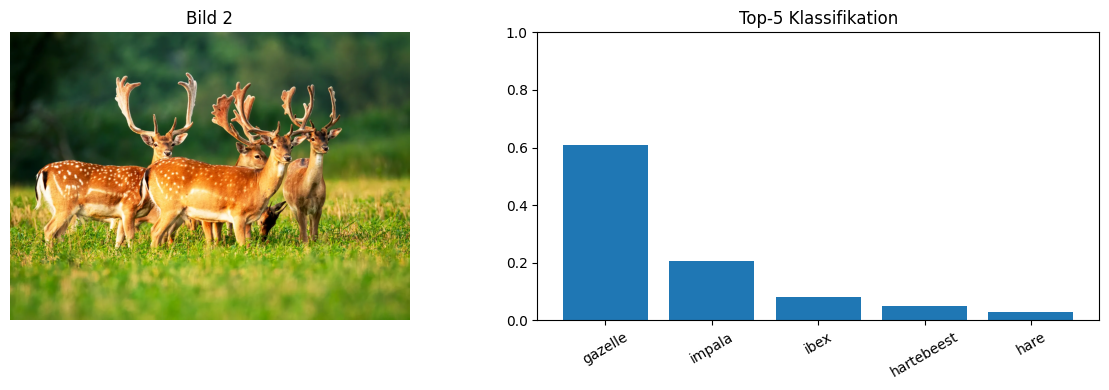

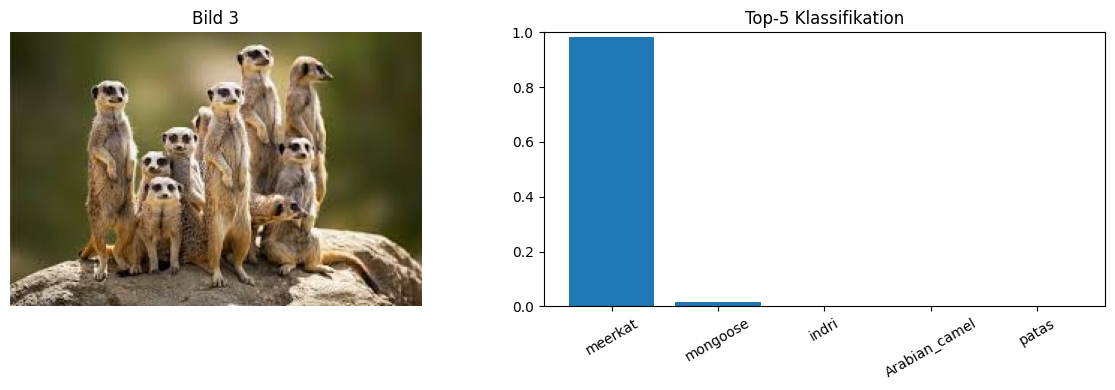

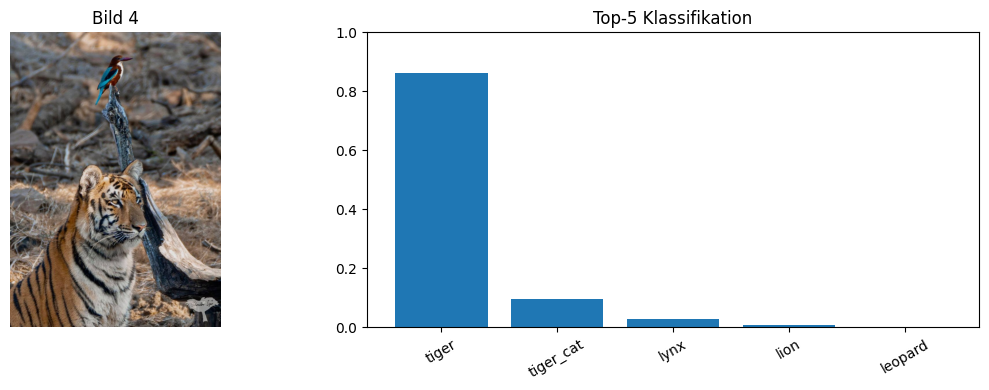

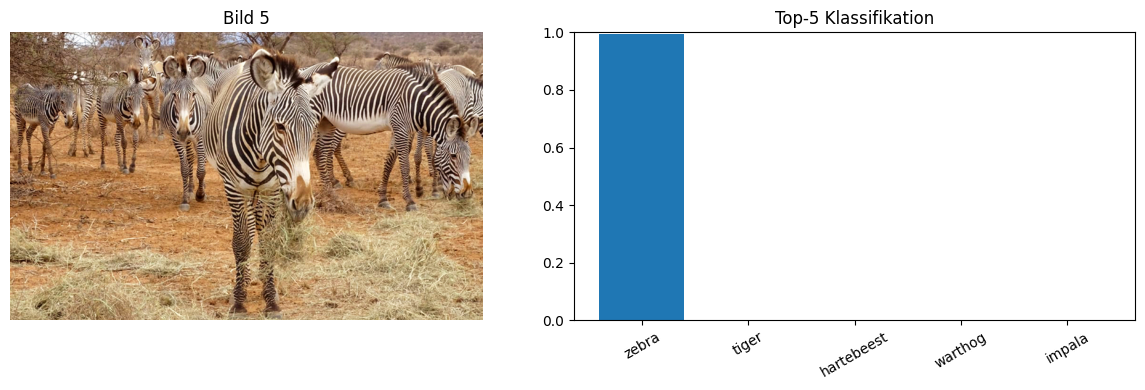

In [ ]:
# In Colab:
# img_path = "/content/drive/MyDrive/DIH-CV-main/images/multi-object"

img_path = "/home/u88m52/projects/DIH-CV/images/multi-object"
result = clf_model.predict(img_path, verbose=False)
print("Anzahl der Bilder im Result:", len(result))

for i, r in enumerate(result):
    # wir laden zuerst das konkrete Bild
    img_path = r.path  
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # wir extrahieren die Top-5 Klassifikationsdaten
    probs = r.probs
    topk = 5
    topk_ids = [int(x) for x in probs.top5[:topk]]
    topk_confs = [float(x) for x in probs.top5conf[:topk]]
    topk_names = [r.names[i] for i in topk_ids]

    # wir plotten alles in Subplots - Bild links, Balkendiagramm rechts
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img_rgb)
    axes[0].axis("off")
    axes[0].set_title(f"Bild {i+1}")

    axes[1].bar(topk_names, topk_confs)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Top-5 Klassifikation")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

Wir haben gerade gesehen: auch beim Multi-Object-Bild kommt nur **eine** Klassifikation heraus.
Die Top-5 Liste kann sich verändern oder “gemischter” wirken — aber:

Wir können daraus **nicht**:
- ablesen, wie viele Objekte im Bild
- wissen, wo sie sich befinden!

## Zusammenfassend...

Wir wissen jetzt:
- wie wir ein Bild laden können
- wie wir ein Klassifikationsmodell laden können
- wie wir eine Inferenz auf einem Testbild / Ordner bekommen können
- wie wir die Ergebnisse visualisieren / darstellen können.

Allerdings gibt es einige Short-Comings:
- für jedes Bild wird genau **eine** Klasse retourniert
- mehrere Objekte gehen in der Wahrscheinlichkeitsverteilung des Resultates unter
- wir können keine Rückschlüsse auf die Anzahl an Objekten am Bild ziehen
- wir wissen nicht, wo sich ein erkanntes Objekt am Bild befindet.

In der nächsten Demo sehen wir diese letzten Punkte genauer an und betrachten Modelle,
die damit besser umgehen können: **Detektionsmodelle**.